# Category RSA — patient vs. control

Same RDM spheres, three measures built coarse -> fine. OTC patients only (last session); controls (first session); exclude sub-017, (sub-108, ses-02). Split by intact hemisphere, never pooled. `hemi='l'` = LH-intact patients vs controls' left; `hemi='r'` = RH-intact vs controls' right.

`fisher_r` stored as Fisher-z; model z directly, `tanh` -> r for figures only. Negative r = distinct voxel patterns (legitimate; betas/z signs not interpreted).

1. **Distinctiveness** (collapsed): preferred category vs the other three, one number per ROI. *Higher = less distinct.*
2. **Geometry, holistic** (omnibus): does the 6-value RDM differ by group? LMM `fisher_r ~ C(pair)*C(group)`, 5-df Wald on interaction.
3. **Geometry, pairwise** (post-hoc): which of the 6 pairs moved? 10k label-shuffle perm, Cohen's d, BH-FDR within ROI x hemi.

All three patient-vs-control, per ROI x hemi. n~11/patient hemi -> power limited.

## 1. Setup

In [33]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.spatial import procrustes
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

sys.path.insert(0, "/user_data/csimmon2/git_repos/sym_pt")
from sym_pt_params import processed_dir

np.random.seed(0)
MNI_CSV     = Path(processed_dir) / "group_results" / "peak_coords" / "peak_coords_mni.csv"
ROIS        = ["face_FFA", "house_PPA", "object_LOC", "word_VWFA"]
CATS4       = ["face", "object", "house", "word"]
N_PERM      = 10_000
HEMIS       = {"l": "left", "r": "right"}
EXCLUDE     = ["sub-017"]
EXCLUDE_SES = [("sub-108", 2)]

## 2. Load + cohort/session filter
OTC -> last session; controls -> first session (matches XS notebook).

In [34]:
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni["subject_id"].isin(EXCLUDE)].copy()
mni["ses_num"] = pd.to_numeric(mni["session"], errors="coerce").astype("Int64")
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni["subject_id"] == bad_sub) & (mni["ses_num"] == bad_ses))]
mni = mni[mni["category"].isin(ROIS) & mni["pair"].notna()].copy()

ls = (mni[mni["group"]=="OTC"].groupby("subject_id")["ses_num"].max()
        .reset_index().rename(columns={"ses_num":"keep"}))
pt = mni[mni["group"]=="OTC"].merge(ls, on="subject_id"); pt = pt[pt["ses_num"]==pt["keep"]].drop(columns="keep")
fs = (mni[mni["status"]=="control"].groupby("subject_id")["ses_num"].min()
        .reset_index().rename(columns={"ses_num":"keep"}))
ct = mni[mni["status"]=="control"].merge(fs, on="subject_id"); ct = ct[ct["ses_num"]==ct["keep"]].drop(columns="keep")
df = pd.concat([pt, ct], ignore_index=True)

df["pair_sorted"] = df["pair"].apply(lambda p: "-".join(sorted(p.split("-"))))
PAIRS_SORTED = sorted(df["pair_sorted"].unique())
assert len(PAIRS_SORTED) == 6, f"expected 6 pairs, got {PAIRS_SORTED}"
df = df.drop(columns=["pair"])
df["is_pt"] = (df["status"] == "patient").astype(int)

print("patients:", df[df.is_pt==1]["subject_id"].nunique(), "| controls:", df[df.is_pt==0]["subject_id"].nunique())
print(df.groupby(["category","hemi","status"])["subject_id"].nunique().unstack(fill_value=0))

patients: 22 | controls: 38
status           control  patient
category   hemi                  
face_FFA   l          38       11
           r          38       11
house_PPA  l          38       11
           r          38       11
object_LOC l          38       11
           r          38       11
word_VWFA  l          38       11
           r          38       11


## 3. Helpers

In [35]:
def stratum(df, roi, hemi):
    s = df[(df["category"] == roi) & (df["hemi"] == hemi)].copy()
    s["group"] = np.where(s["is_pt"] == 1, "patient", "control")
    return s

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return np.nan if sp == 0 else (np.mean(x) - np.mean(y)) / sp

def perm_test(x, y, n=N_PERM, rng=None):
    rng = rng or np.random.default_rng(0)
    obs = np.mean(x) - np.mean(y)
    pool = np.concatenate([x, y]); nx = len(x)
    null = np.empty(n)
    for i in range(n):
        rng.shuffle(pool); null[i] = np.mean(pool[:nx]) - np.mean(pool[nx:])
    return obs, (np.sum(np.abs(null) >= abs(obs)) + 1) / (n + 1)

def bh_fdr(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 1.0
    for k in range(m-1, -1, -1):
        i = order[k]; run = min(run, p[i] * m / (k+1)); adj[i] = run
    return adj

def subj_rdm(sub_rows):
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row["pair_sorted"].split("-"); i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row["fisher_r"])
    return M

def coords(sim_mat):
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity="precomputed", random_state=0,
               normalized_stress="auto").fit_transform(1.0 - M)

def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s.group == grp].groupby("subject_id")
            if g["pair_sorted"].nunique() == 6}

## 4. Distinctiveness (collapsed)
Preferred category vs. the other three (mean correlation), one value per subject. **Higher = less distinct** (preferred blends with the rest). Patient vs control, 10k perm. `diff = pt - ctrl`; positive = patients *less* distinct.

In [36]:
dist = (df.drop_duplicates(["subject_id","category","hemi"])
          [["subject_id","category","hemi","is_pt","liu_distinctiveness"]].copy())
dist["group"] = np.where(dist["is_pt"] == 1, "patient", "control")

rng = np.random.default_rng(0)
rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = dist[(dist.category == roi) & (dist.hemi == hemi)]
        x = s.loc[s.group=="patient","liu_distinctiveness"].dropna().values
        y = s.loc[s.group=="control","liu_distinctiveness"].dropna().values
        if len(x) < 2 or len(y) < 2:
            rows.append(dict(roi=roi, hemi=hemi, n_pt=len(x), n_ct=len(y), diff=np.nan, d=np.nan, p=np.nan)); continue
        diff, p = perm_test(x, y, rng=rng)
        rows.append(dict(roi=roi, hemi=hemi, n_pt=len(x), n_ct=len(y),
                         ctrl=y.mean(), pt=x.mean(), diff=diff, d=cohen_d(x, y), p=p))
distinct = pd.DataFrame(rows)
distinct.round(4)

,roi,hemi,n_pt,n_ct,ctrl,pt,diff,d,p
0,face_FFA,l,11,38,0.6711,0.5694,-0.1016,-0.3028,0.3770
1,face_FFA,r,11,37,0.5476,0.7184,0.1708,0.4610,0.1792
2,house_PPA,l,11,38,0.4359,0.1159,-0.3200,-0.4374,0.2128
3,house_PPA,r,11,38,0.4951,0.8260,0.3308,0.4141,0.2360
4,object_LOC,l,11,38,1.0507,1.0350,-0.0158,-0.0365,0.9128
5,object_LOC,r,11,38,1.2320,1.2795,0.0475,0.0956,0.7815
6,word_VWFA,l,11,37,0.6374,0.5749,-0.0624,-0.1454,0.6724
7,word_VWFA,r,11,37,0.3648,0.7250,0.3601,0.7369,0.0406


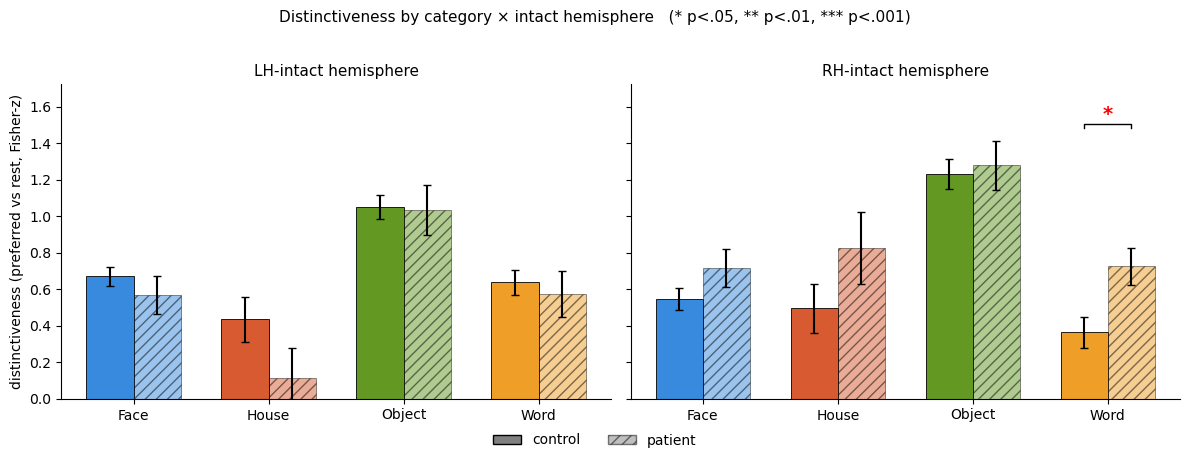

In [50]:
# ─── Distinctiveness (measure 1): 4 categories × intact hemi, WTA style ──
from matplotlib.patches import Patch

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30', 'object': '#639922', 'word': '#EF9F27'}
ROI_FOR = {'face': 'face_FFA', 'house': 'house_PPA', 'object': 'object_LOC', 'word': 'word_VWFA'}
CATS_PANEL = ['face', 'house', 'object', 'word']

def _stars(p):
    if np.isnan(p): return ''
    if p < .001: return '***'
    if p < .01:  return '**'
    if p < .05:  return '*'
    return ''

# per-subject distinctiveness (preferred-vs-rest), one value per category/hemi
dd = (df.drop_duplicates(["subject_id","category","hemi"])
        [["subject_id","category","hemi","is_pt","liu_distinctiveness"]].copy())
dd["group"] = np.where(dd["is_pt"]==1, "patient", "control")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, h, hlabel in zip(axes, ['l','r'], ['LH-intact','RH-intact']):
    x = np.arange(len(CATS_PANEL)); w = 0.35; max_top = 0
    for offset, grp, alpha, hatch in [(-w/2,'control',1.0,''), (+w/2,'patient',0.5,'///')]:
        means, sems = [], []
        for c in CATS_PANEL:
            v = dd[(dd.category==ROI_FOR[c]) & (dd.hemi==h) & (dd.group==grp)]['liu_distinctiveness'].dropna().values
            means.append(v.mean() if len(v) else np.nan)
            sems.append(v.std()/np.sqrt(len(v)) if len(v)>1 else 0)
        ax.bar(x+offset, means, w, yerr=sems, color=[CAT_COLORS[c] for c in CATS_PANEL],
               alpha=alpha, hatch=hatch, edgecolor='black', linewidth=0.6, capsize=3)
        max_top = max(max_top, np.nanmax([m+s for m,s in zip(means,sems)]))

    by = max_top*1.05; bh = max_top*0.015
    for xi, c in enumerate(CATS_PANEL):
        row = distinct[(distinct.roi==ROI_FOR[c]) & (distinct.hemi==h)]
        st = _stars(float(row['p'].iloc[0])) if len(row) else ''
        if st:
            ax.plot([xi-w/2,xi-w/2,xi+w/2,xi+w/2],[by,by+bh,by+bh,by], color='black', lw=1)
            ax.text(xi, by+bh, st, ha='center', va='bottom', color='red', fontsize=14, fontweight='bold')

    ax.set_ylim(0, max_top*1.22)
    ax.set_xticks(x); ax.set_xticklabels([c.title() for c in CATS_PANEL], fontsize=10)
    ax.set_title(f'{hlabel} hemisphere', fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    if h=='l': ax.set_ylabel('distinctiveness (preferred vs rest, Fisher-z)', fontsize=10)

handles = [Patch(facecolor='gray', edgecolor='black', label='control'),
           Patch(facecolor='gray', alpha=0.5, edgecolor='black', hatch='///', label='patient')]
fig.legend(handles=handles, ncol=2, frameon=False, fontsize=10, loc='lower center', bbox_to_anchor=(0.5,-0.02))
fig.suptitle('Distinctiveness by category × intact hemisphere   (* p<.05, ** p<.01, *** p<.001)', fontsize=11)
plt.tight_layout(rect=[0,0.03,1,0.96])
plt.savefig(FIG_DIR / 'distinctiveness_bars.png', dpi=300, bbox_inches='tight')
plt.show()

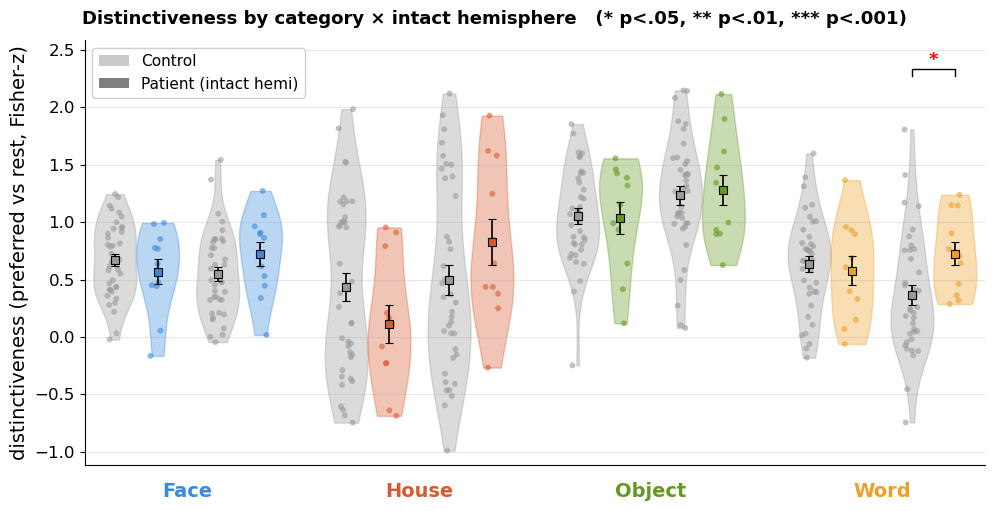

In [51]:
# ─── Distinctiveness (measure 1): violins matching sum-sel layout ────────
from matplotlib.patches import Patch

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30', 'object': '#639922', 'word': '#EF9F27'}
ROI_FOR = {'face': 'face_FFA', 'house': 'house_PPA', 'object': 'object_LOC', 'word': 'word_VWFA'}
CATS_PANEL = ['face', 'house', 'object', 'word']
CTRL_COLOR = '#999999'

def _stars(p):
    if np.isnan(p): return ''
    return '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''

dd = (df.drop_duplicates(["subject_id","category","hemi"])
        [["subject_id","category","hemi","is_pt","liu_distinctiveness"]].copy())
dd["group"] = np.where(dd["is_pt"]==1, "patient", "control")

INTRA, INTER, CAT_GAP = 0.5, 0.7, 1.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(10, 5))
RNG = np.random.RandomState(42)
cat_centers = []

allv = dd['liu_distinctiveness'].dropna().values
gmin, gmax = allv.min(), allv.max()
brack_h = (gmax - gmin) * 0.02

def _get(cat, h, grp):
    return dd[(dd.category==ROI_FOR[cat]) & (dd.hemi==h) & (dd.group==grp)]['liu_distinctiveness'].dropna().values

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    groups = [
        (_get(cat,'l','control'), positions[0], CTRL_COLOR),
        (_get(cat,'l','patient'), positions[1], cat_color),
        (_get(cat,'r','control'), positions[2], CTRL_COLOR),
        (_get(cat,'r','patient'), positions[3], cat_color),
    ]
    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.09, 0.09, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals, color=col, alpha=0.6, s=18, edgecolors='none', zorder=3)
        ax.errorbar(pos, vals.mean(), yerr=vals.std()/np.sqrt(max(len(vals),1)),
                    color='black', marker='s', markersize=6, markerfacecolor=col,
                    markeredgecolor='black', markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    for (h, x_l, x_r) in [('l', positions[0], positions[1]), ('r', positions[2], positions[3])]:
        row = distinct[(distinct.roi==ROI_FOR[cat]) & (distinct.hemi==h)]
        stars = _stars(float(row['p'].iloc[0])) if len(row) else ''
        if not stars: continue
        by = gmax + brack_h * 2
        ax.plot([x_l, x_l, x_r, x_r], [by, by+brack_h, by+brack_h, by], color='black', lw=1, zorder=6)
        ax.text((x_l+x_r)/2, by+brack_h, stars, ha='center', va='bottom', color='red', fontsize=13, fontweight='bold', zorder=6)

ax.set_xticks([])
ax.set_ylabel('distinctiveness (preferred vs rest, Fisher-z)', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
            color=CAT_COLORS[cat], ha='center', va='top', transform=ax.get_xaxis_transform())

total_width = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
ax.set_xlim(-0.35, total_width + 0.35)
yrange = gmax - gmin
ax.set_ylim(gmin - 0.04*yrange, gmax + 0.14*yrange)

legend_elements = [Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control'),
                   Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi)')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, framealpha=0.9)

plt.suptitle('Distinctiveness by category × intact hemisphere   (* p<.05, ** p<.01, *** p<.001)',
             fontsize=13, fontweight='bold', y=0.99)
plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
plt.savefig(FIG_DIR / 'distinctiveness_violin.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Geometry — holistic (omnibus)
Does the full 6-value RDM differ by group? MixedLM, subject random intercept; 5-df joint Wald on `C(pair_sorted):C(group)`.

In [37]:
omni = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi).dropna(subset=["fisher_r","group","pair_sorted"]).reset_index(drop=True)
        npt = int((s.group=="patient").groupby(s.subject_id).any().sum())
        nct = int((s.group=="control").groupby(s.subject_id).any().sum())
        if npt < 2 or nct < 2:
            omni.append(dict(roi=roi, hemi=hemi, n_pt=npt, n_ct=nct, df=np.nan, chi2=np.nan, p=np.nan)); continue
        m = smf.mixedlm("fisher_r ~ C(pair_sorted) * C(group)", s, groups=s["subject_id"]).fit(reml=True)
        inter = [t for t in m.params.index if (":" in t and "C(pair_sorted)" in t and "C(group)" in t)]
        R = np.zeros((len(inter), len(m.params)))
        for i, t in enumerate(inter):
            R[i, list(m.params.index).index(t)] = 1.0
        w = m.wald_test(R, scalar=True)
        omni.append(dict(roi=roi, hemi=hemi, n_pt=npt, n_ct=nct, df=int(len(inter)),
                         chi2=float(np.squeeze(w.statistic)), p=float(np.squeeze(w.pvalue))))
omni = pd.DataFrame(omni)
omni

,roi,hemi,n_pt,n_ct,df,chi2,p
0,face_FFA,l,11,38,5,5.179426,0.394378
1,face_FFA,r,11,37,5,35.649937,0.000001
2,house_PPA,l,11,38,5,3.976635,0.552785
3,house_PPA,r,11,38,5,5.073816,0.406938
4,object_LOC,l,11,38,5,5.193113,0.392770
5,object_LOC,r,11,38,5,9.402034,0.094064
6,word_VWFA,l,11,37,5,2.257492,0.812489
7,word_VWFA,r,11,37,5,19.863340,0.001326


## 6. Geometry — pairwise (post-hoc)
Which of the 6 pairs moved? 10k label-shuffle perm, Cohen's d, BH-FDR within ROI x hemi. Survivors under a *null* omnibus are exploratory.

In [38]:
rng = np.random.default_rng(0)
rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi)
        block = []
        for pr in PAIRS_SORTED:
            sp = s[s["pair_sorted"] == pr]
            x = sp.loc[sp.group=="patient","fisher_r"].dropna().values
            y = sp.loc[sp.group=="control","fisher_r"].dropna().values
            if len(x) < 2 or len(y) < 2:
                block.append(dict(roi=roi, hemi=hemi, pair=pr, n_pt=len(x), n_ct=len(y),
                                  diff=np.nan, d=np.nan, p=np.nan)); continue
            diff, p = perm_test(x, y, rng=rng)
            block.append(dict(roi=roi, hemi=hemi, pair=pr, n_pt=len(x), n_ct=len(y),
                              diff=diff, d=cohen_d(x, y), p=p))
        b = pd.DataFrame(block)
        b["p_fdr"] = bh_fdr(b["p"].fillna(1.0).values)
        b["survives"] = (b["p_fdr"] < .05) & b["p"].notna()
        rows.append(b)
posthoc = pd.concat(rows, ignore_index=True)
posthoc.round(4)

,roi,hemi,pair,n_pt,n_ct,diff,d,p,p_fdr,survives
0,face_FFA,l,face-house,11,38,-0.0497,-0.1099,0.7482,0.8979,False
1,face_FFA,l,face-object,11,38,-0.0092,-0.0248,0.9431,0.9431,False
2,face_FFA,l,face-word,11,38,-0.2460,-0.6384,0.0687,0.4122,False
3,face_FFA,l,house-object,11,38,-0.0894,-0.1670,0.6264,0.8979,False
4,face_FFA,l,house-word,11,38,0.0781,0.1389,0.6829,0.8979,False
5,face_FFA,l,object-word,11,38,0.0484,0.1153,0.7387,0.8979,False
6,face_FFA,r,face-house,11,37,-0.1772,-0.3994,0.2575,0.3862,False
7,face_FFA,r,face-object,11,37,0.0568,0.1262,0.7068,0.7068,False
8,face_FFA,r,face-word,11,37,0.6329,1.3552,0.0007,0.0042,True
9,face_FFA,r,house-object,11,37,-0.2264,-0.4243,0.2227,0.3862,False


## 7. Survivors
Pairwise survivors per stratum (cross-check against omnibus: ignore those under a null omnibus).

In [39]:
surv = posthoc[posthoc["survives"]].copy()
if len(surv):
    print(surv[["roi","hemi","pair","diff","d","p","p_fdr"]].round(4).to_string(index=False))
else:
    print("No pairs survive BH-FDR; report Step 6 with effect sizes, frame as power-limited.")

      roi hemi        pair    diff       d      p  p_fdr
 face_FFA    r   face-word  0.6329  1.3552 0.0007 0.0042
house_PPA    l face-object -0.5182 -0.9652 0.0074 0.0222
house_PPA    l object-word -0.5999 -1.2593 0.0003 0.0018
word_VWFA    r  house-word  0.6311  1.0341 0.0043 0.0258


## 8. RDM panels + Procrustes (viz)
Per ROI: control mean, LH-intact mean, RH-intact mean RDM (r-space). Procrustes disparity = misfit of each subject's 4-category config to control-mean (controls leave-one-out). Not inferential.

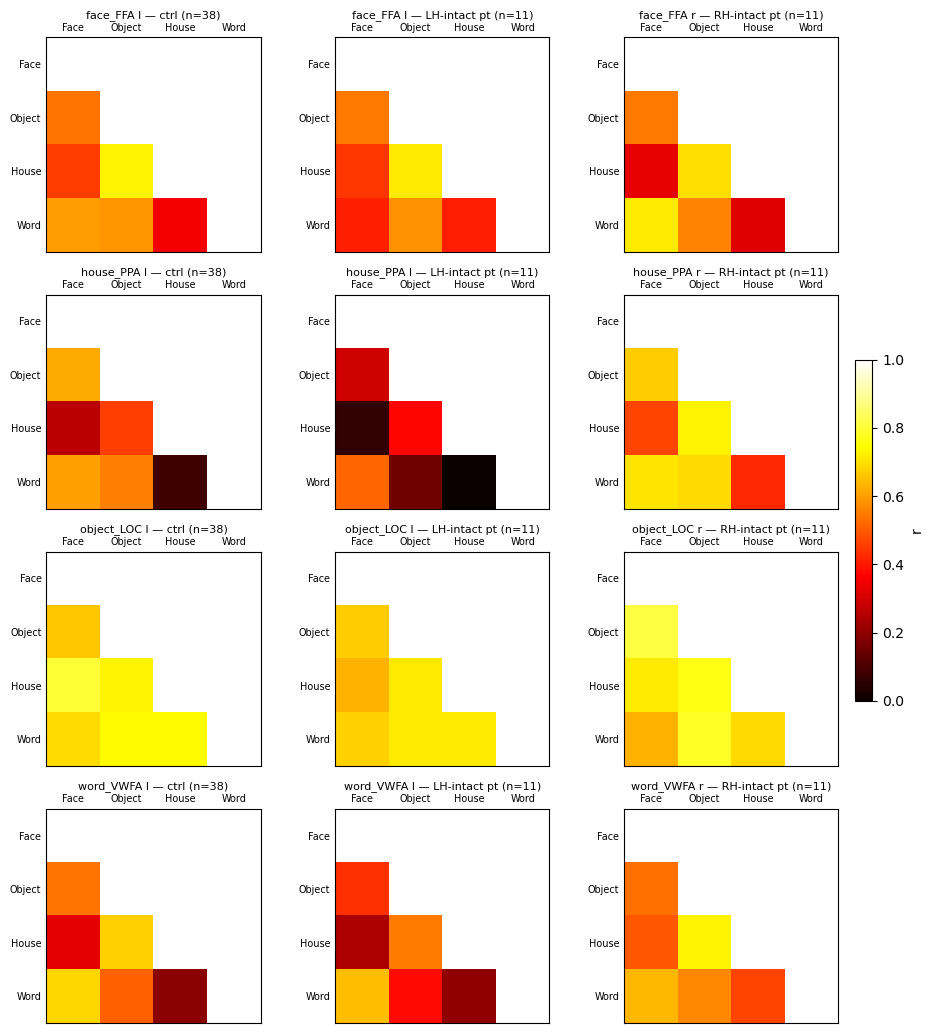

Procrustes disparity, patient vs control (higher = worse fit to control geometry):
       roi hemi  mean_pt  mean_ct    diff      p
  face_FFA    l   0.2610   0.2750 -0.0140 0.8093
  face_FFA    r   0.3233   0.2503  0.0729 0.1737
 house_PPA    l   0.3970   0.4271 -0.0301 0.7761
 house_PPA    r   0.3756   0.3463  0.0293 0.7377
object_LOC    l   0.4798   0.4358  0.0440 0.5726
object_LOC    r   0.4497   0.4724 -0.0226 0.7563
 word_VWFA    l   0.3053   0.2528  0.0525 0.4595
 word_VWFA    r   0.3484   0.1780  0.1704 0.0039


In [40]:
def mean_rdm(s, grp):
    mats = list(subj_mats(s, grp).values())
    return (np.nanmean(np.stack(mats), axis=0), len(mats)) if mats else (np.full((4,4), np.nan), 0)

LAB = ["Face","Object","House","Word"]
fig, axes = plt.subplots(len(ROIS), 3, figsize=(11, 3.2*len(ROIS)))
for ri, roi in enumerate(ROIS):
    sl = stratum(df, roi, "l"); sr = stratum(df, roi, "r")
    panels = [(mean_rdm(sl, "control"), f"{roi} l — ctrl"),
              (mean_rdm(sl, "patient"), f"{roi} l — LH-intact pt"),
              (mean_rdm(sr, "patient"), f"{roi} r — RH-intact pt")]
    for ci, ((M, nrdm), ttl) in enumerate(panels):
        ax = axes[ri, ci]
        M = np.where(np.triu(np.ones_like(M, bool), k=1), np.nan, M)  # hide upper triangle (# if want full matrix))
        im = ax.imshow(M, cmap="hot", vmin=0, vmax=1)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LAB, fontsize=7); ax.set_yticklabels(LAB, fontsize=7)
        ax.xaxis.tick_top(); ax.set_title(f"{ttl} (n={nrdm})", fontsize=8, pad=14)
        ax.tick_params(length=0)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="r")
plt.show()

disp_rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi)
        ctrl = subj_mats(s, "control"); pat = subj_mats(s, "patient")
        if len(ctrl) < 2: continue
        cmats = np.stack(list(ctrl.values())); cm = coords(np.nanmean(cmats, axis=0))
        for k, sid in enumerate(ctrl):
            loo = np.nanmean(np.delete(cmats, k, axis=0), axis=0)
            _, _, d = procrustes(coords(loo), coords(ctrl[sid]))
            disp_rows.append(dict(roi=roi, hemi=hemi, group="control", disparity=d))
        for sid, M in pat.items():
            _, _, d = procrustes(cm, coords(M))
            disp_rows.append(dict(roi=roi, hemi=hemi, group="patient", disparity=d))
disp = pd.DataFrame(disp_rows)
rng = np.random.default_rng(0)
dt = []
for (roi, hemi), g in disp.groupby(["roi","hemi"]):
    x = g.loc[g.group=="patient","disparity"].values; y = g.loc[g.group=="control","disparity"].values
    if len(x) < 2 or len(y) < 2: continue
    diff, p = perm_test(x, y, rng=rng)
    dt.append(dict(roi=roi, hemi=hemi, mean_pt=x.mean(), mean_ct=y.mean(), diff=diff, p=p))
print("Procrustes disparity, patient vs control (higher = worse fit to control geometry):")
print(pd.DataFrame(dt).round(4).to_string(index=False))

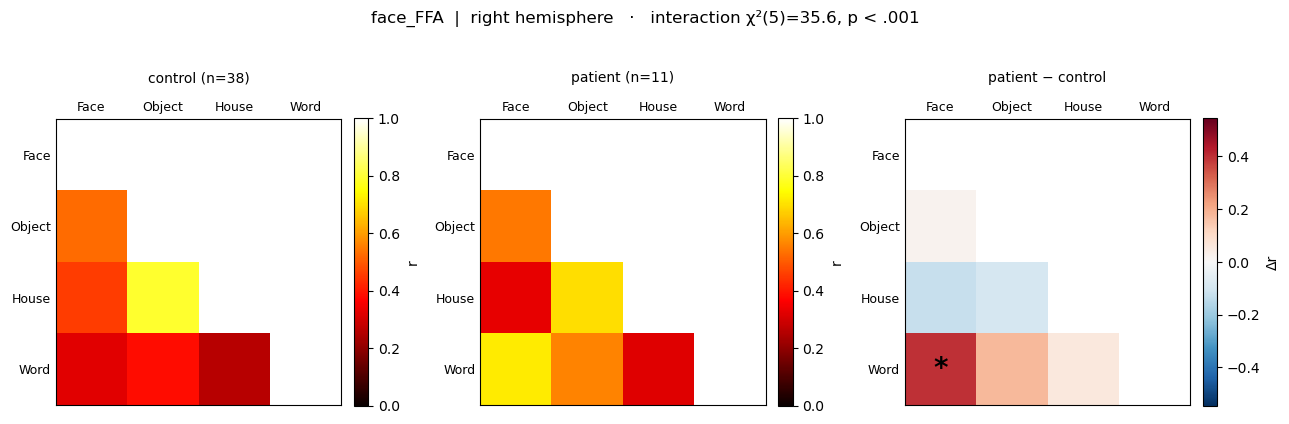

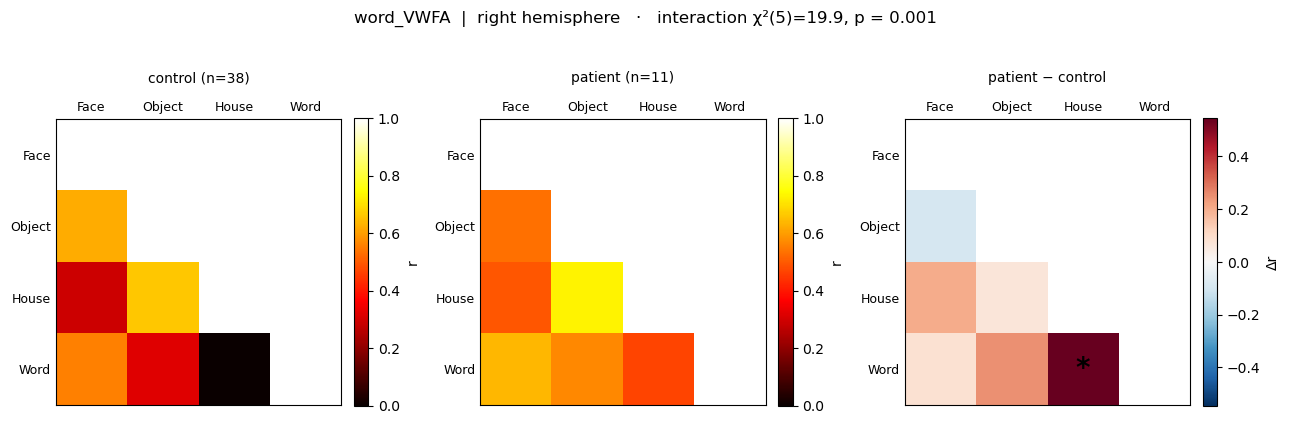

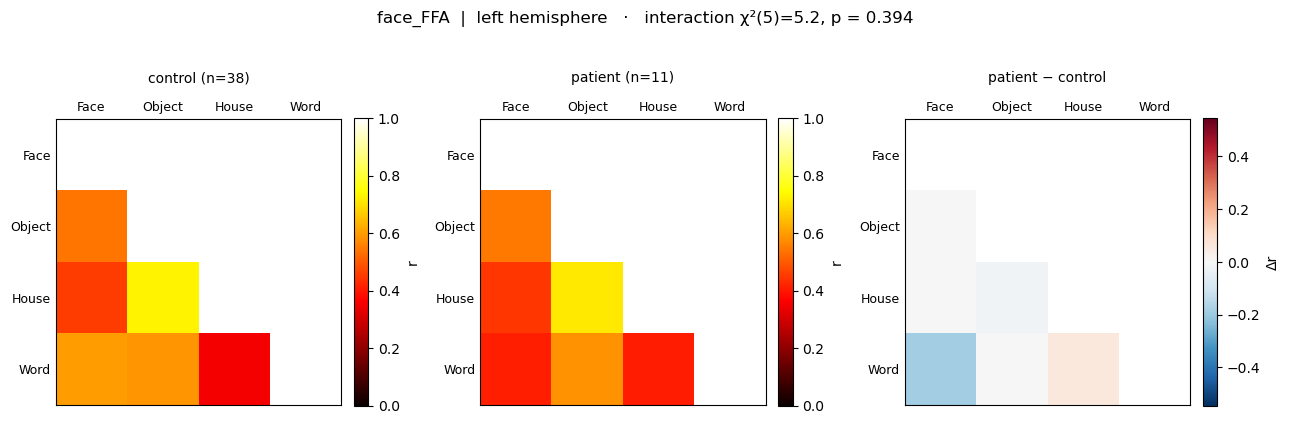

In [54]:
# ─── Measures 2+3: RDM triptych (ctrl | patient | difference) per ROI ────
def mean_rdm(s, grp):
    mats = list(subj_mats(s, grp).values())
    return (np.nanmean(np.stack(mats), axis=0), len(mats)) if mats else (np.full((4,4), np.nan), 0)

LAB = ['Face','Object','House','Word']

def _mask_upper(M):
    return np.where(np.triu(np.ones_like(M, bool), k=1), np.nan, M)

PLOT = [('face_FFA','r'), ('word_VWFA','r'), ('face_FFA','l')]

# global symmetric scale across all difference panels
dmax = 0.0
for roi, hemi in PLOT:
    s = stratum(df, roi, hemi)
    C, _ = mean_rdm(s, 'control'); P, _ = mean_rdm(s, 'patient')
    D = P - C; np.fill_diagonal(D, np.nan)
    if np.isfinite(D).any():
        dmax = max(dmax, np.nanmax(np.abs(D)))

def plot_rdm_diff(roi, hemi, gdmax):
    s = stratum(df, roi, hemi)
    C, nc = mean_rdm(s, 'control')
    P, npt = mean_rdm(s, 'patient')
    D = P - C
    np.fill_diagonal(D, np.nan)

    o = omni[(omni.roi==roi) & (omni.hemi==hemi)].iloc[0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))

    specs = [(_mask_upper(C), f'control (n={nc})', 'hot', 0, 1, 'r'),
             (_mask_upper(P), f'patient (n={npt})', 'hot', 0, 1, 'r'),
             (_mask_upper(D), 'patient − control', 'RdBu_r', -gdmax, gdmax, 'Δr')]
    for ax, (M, ttl, cmap, vmin, vmax, cbar_lab) in zip(axes, specs):
        im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LAB, fontsize=9); ax.set_yticklabels(LAB, fontsize=9)
        ax.xaxis.tick_top(); ax.tick_params(length=0)
        ax.set_title(ttl, fontsize=10, pad=14)
        if cbar_lab == 'Δr':
            for pr in PAIRS_SORTED:
                row = posthoc[(posthoc.roi==roi)&(posthoc.hemi==hemi)&(posthoc.pair==pr)]
                if len(row) and bool(row['survives'].iloc[0]):
                    a, b = pr.split('-'); i, j = LAB.index(a.title()), LAB.index(b.title())
                    lo, hi = max(i,j), min(i,j)
                    ax.text(hi, lo, '*', ha='center', va='center', color='black',
                            fontsize=20, fontweight='bold')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_lab)

    p_str = "p < .001" if o["p"] < .001 else f"p = {o['p']:.3f}"
    fig.suptitle(f'{roi}  |  {HEMIS[hemi]} hemisphere   ·   '
                 f'interaction χ²(5)={o["chi2"]:.1f}, {p_str}',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'rdm_diff_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()

for roi, hemi in PLOT:
    plot_rdm_diff(roi, hemi, dmax)
    
    

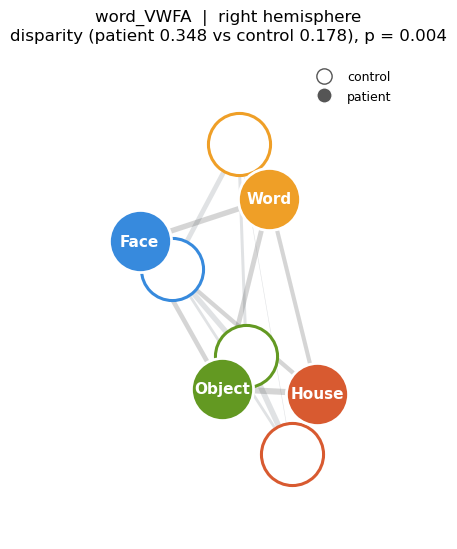

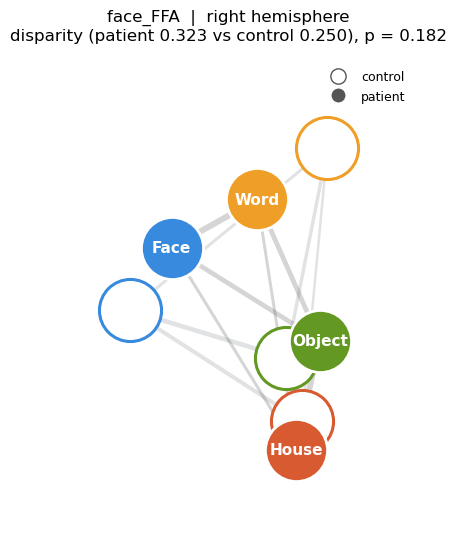

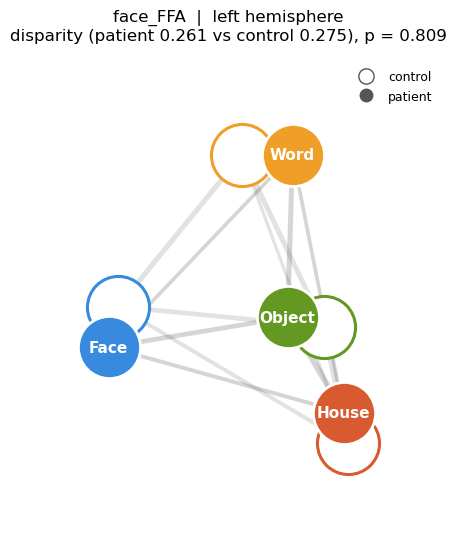

In [57]:
# ─── Procrustes/MDS configuration plots — selected ROI × hemi ────────────
from matplotlib.patches import FancyArrowPatch

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30', 'object': '#639922', 'word': '#EF9F27'}
PAIRS6 = [('face','object'),('face','house'),('face','word'),
          ('house','object'),('object','word'),('house','word')]

def aligned_configs(s):
    cmats = list(subj_mats(s, 'control').values())
    pmats = list(subj_mats(s, 'patient').values())
    if len(cmats) < 2 or len(pmats) < 1:
        return None
    csim = np.nanmean(np.stack(cmats), axis=0)
    psim = np.nanmean(np.stack(pmats), axis=0)
    mtx1, mtx2, _ = procrustes(coords(csim), coords(psim))
    return csim, psim, mtx1, mtx2

def plot_procrustes(roi, hemi):
    s = stratum(df, roi, hemi)
    out = aligned_configs(s)
    if out is None:
        return
    csim, psim, c_xy, p_xy = out

    # per-subject disparities (matches the table / test)
    ctrl = subj_mats(s, 'control'); pat = subj_mats(s, 'patient')
    cmats = np.stack(list(ctrl.values()))
    cm = coords(np.nanmean(cmats, axis=0))
    cd, pd_ = [], []
    for k, sid in enumerate(ctrl):
        loo = np.nanmean(np.delete(cmats, k, axis=0), axis=0)
        _, _, d = procrustes(coords(loo), coords(ctrl[sid])); cd.append(d)
    for sid, M in pat.items():
        _, _, d = procrustes(cm, coords(M)); pd_.append(d)
    diff, pval = perm_test(np.array(pd_), np.array(cd), rng=np.random.default_rng(0))
    mean_pt, mean_ct = np.mean(pd_), np.mean(cd)

    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_facecolor('white')

    # control scaffold (faint gray, weighted by r)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(csim[i, j]), 0, 1)
        ax.plot([c_xy[i,0], c_xy[j,0]], [c_xy[i,1], c_xy[j,1]], color='#9aa0a6',
                lw=0.4 + r*5.5, alpha=0.30, solid_capstyle='round', zorder=1)

    # patient edges (dark, weighted by r)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(psim[i, j]), 0, 1)
        ax.plot([p_xy[i,0], p_xy[j,0]], [p_xy[i,1], p_xy[j,1]], color='#444',
                lw=0.4 + r*5.5, alpha=0.22, solid_capstyle='round', zorder=2)

    # nodes: control open, patient filled
    for k, cat in enumerate(CATS4):
        ax.scatter(*c_xy[k], s=2000, facecolor='white', edgecolor=CAT_COLORS[cat],
                   linewidth=2.2, zorder=4)
        ax.scatter(*p_xy[k], s=2000, facecolor=CAT_COLORS[cat], edgecolor='white',
                   linewidth=2.0, zorder=5)
        ax.annotate(cat.capitalize(), p_xy[k], fontsize=11, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)

    p_str = "p < .001" if pval < .001 else f"p = {pval:.3f}"
    ax.set_title(f'{roi}  |  {HEMIS[hemi]} hemisphere\n'
                 f'disparity (patient {mean_pt:.3f} vs control {mean_ct:.3f}), {p_str}',
                 fontsize=12, pad=14)
    ax.set_aspect('equal'); ax.axis('off')
    pad = 0.35
    allxy = np.vstack([c_xy, p_xy])
    ax.set_xlim(allxy[:,0].min()-pad, allxy[:,0].max()+pad)
    ax.set_ylim(allxy[:,1].min()-pad, allxy[:,1].max()+pad)

    legend = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                         markeredgecolor='#555', markersize=11, label='control'),
              plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#555',
                         markersize=11, label='patient')]
    ax.legend(handles=legend, loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f'procrustes_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()

SELECTED = [("word_VWFA", "r"), ("face_FFA", "r"), ("face_FFA", "l")]
for roi, hemi in SELECTED:
    plot_procrustes(roi, hemi)

In [55]:
# ─── Results values for write-up (single source) ─────────────────────────
print("="*60); print("MEASURE 1 — distinctiveness (preferred vs rest)"); print("="*60)
print(distinct[['roi','hemi','n_pt','n_ct','ctrl','pt','diff','d','p']].round(4).to_string(index=False))

print("\n"+"="*60); print("MEASURE 2 — interaction (pair × group, Wald χ²)"); print("="*60)
print(omni[['roi','hemi','n_pt','n_ct','df','chi2','p']].round(6).to_string(index=False))

print("\n"+"="*60); print("MEASURE 3 — per-pair (perm, BH-FDR within ROI×hemi)"); print("="*60)
print(posthoc[['roi','hemi','pair','n_pt','n_ct','diff','d','p','p_fdr','survives']].round(4).to_string(index=False))

print("\n"+"="*60); print("MEASURE 4 — Procrustes disparity (perm)"); print("="*60)
disp_rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi)
        ctrl = subj_mats(s, 'control'); pat = subj_mats(s, 'patient')
        if len(ctrl) < 2 or len(pat) < 1: continue
        cmats = np.stack(list(ctrl.values())); cm = coords(np.nanmean(cmats, axis=0))
        cd, pd_ = [], []
        for k, sid in enumerate(ctrl):
            loo = np.nanmean(np.delete(cmats, k, axis=0), axis=0)
            _, _, dd_ = procrustes(coords(loo), coords(ctrl[sid])); cd.append(dd_)
        for sid, M in pat.items():
            _, _, dd_ = procrustes(cm, coords(M)); pd_.append(dd_)
        diff, p = perm_test(np.array(pd_), np.array(cd), rng=np.random.default_rng(0))
        disp_rows.append(dict(roi=roi, hemi=hemi, mean_ct=np.mean(cd), mean_pt=np.mean(pd_), diff=diff, p=p))
print(pd.DataFrame(disp_rows).round(4).to_string(index=False))

MEASURE 1 — distinctiveness (preferred vs rest)
       roi hemi  n_pt  n_ct   ctrl     pt    diff       d      p
  face_FFA    l    11    38 0.6711 0.5694 -0.1016 -0.3028 0.3770
  face_FFA    r    11    37 0.5476 0.7184  0.1708  0.4610 0.1792
 house_PPA    l    11    38 0.4359 0.1159 -0.3200 -0.4374 0.2128
 house_PPA    r    11    38 0.4951 0.8260  0.3308  0.4141 0.2360
object_LOC    l    11    38 1.0507 1.0350 -0.0158 -0.0365 0.9128
object_LOC    r    11    38 1.2320 1.2795  0.0475  0.0956 0.7815
 word_VWFA    l    11    37 0.6374 0.5749 -0.0624 -0.1454 0.6724
 word_VWFA    r    11    37 0.3648 0.7250  0.3601  0.7369 0.0406

MEASURE 2 — interaction (pair × group, Wald χ²)
       roi hemi  n_pt  n_ct  df      chi2        p
  face_FFA    l    11    38   5  5.179426 0.394378
  face_FFA    r    11    37   5 35.649937 0.000001
 house_PPA    l    11    38   5  3.976635 0.552785
 house_PPA    r    11    38   5  5.073816 0.406938
object_LOC    l    11    38   5  5.193113 0.392770
object_LOC  